# Criando dataset para calcular a taxa de presença por deputado:


In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import plotly.express as px

df_deputados = pd.read_json('../../data/processed/deputados.json') 
df_eventos = pd.read_csv('../../data/processed/eventos.csv')
df_presencas = pd.read_csv('../../data/processed/presencas.csv') 

## 1. Presença por Deputado:


In [5]:
# Filtra só Sessão Deliberativa em df_eventos
df_sessoes = (
    df_eventos
    .loc[df_eventos["descricaoTipo"].eq("Sessão Deliberativa"),
         ["id", "dataHoraInicio", "descricaoTipo"]]
    .rename(columns={"id": "id_evento"})
)
total_sessoes = df_sessoes["id_evento"].nunique()
total_sessoes

392

In [7]:
# Pega apenas id_evento e id_deputado de presenças, remove duplicados
df_presencas_min = (
    df_presencas[["id_evento", "id_deputado"]]
    .drop_duplicates()
    .copy()
)

df_presencas_min

,id_evento,id_deputado
0,58552,69871
1,58552,73466
2,58552,73696
3,58552,74057
4,58552,74200
...,...,...
564076,79992,230957
564077,79992,231911
564078,79992,233592
564079,79992,233594


In [10]:
# Merge sessões x presenças → cada linha é (sessão, deputado)
df_sessoes_pres = df_sessoes.merge(
    df_presencas_min,
    on="id_evento",
    how="left"
).drop_duplicates(["id_evento", "id_deputado"])

df_sessoes_pres

,id_evento,dataHoraInicio,descricaoTipo,id_deputado
0,59265,2020-02-04T19:00,Sessão Deliberativa,66179.0
1,59265,2020-02-04T19:00,Sessão Deliberativa,66828.0
2,59265,2020-02-04T19:00,Sessão Deliberativa,67138.0
3,59265,2020-02-04T19:00,Sessão Deliberativa,68720.0
4,59265,2020-02-04T19:00,Sessão Deliberativa,69871.0
...,...,...,...,...
171614,79645,2025-10-07T13:55,Sessão Deliberativa,231911.0
171615,79645,2025-10-07T13:55,Sessão Deliberativa,233218.0
171616,79645,2025-10-07T13:55,Sessão Deliberativa,233592.0
171617,79645,2025-10-07T13:55,Sessão Deliberativa,233594.0


In [12]:
# Cria flag de presença (0/1)

df_sessoes_pres["presente"] = np.where(
    df_sessoes_pres["id_deputado"].notna(),
    1,
    0
)

df_sessoes_pres

,id_evento,dataHoraInicio,descricaoTipo,id_deputado,presente
0,59265,2020-02-04T19:00,Sessão Deliberativa,66179.0,1
1,59265,2020-02-04T19:00,Sessão Deliberativa,66828.0,1
2,59265,2020-02-04T19:00,Sessão Deliberativa,67138.0,1
3,59265,2020-02-04T19:00,Sessão Deliberativa,68720.0,1
4,59265,2020-02-04T19:00,Sessão Deliberativa,69871.0,1
...,...,...,...,...,...
171614,79645,2025-10-07T13:55,Sessão Deliberativa,231911.0,1
171615,79645,2025-10-07T13:55,Sessão Deliberativa,233218.0,1
171616,79645,2025-10-07T13:55,Sessão Deliberativa,233592.0,1
171617,79645,2025-10-07T13:55,Sessão Deliberativa,233594.0,1


In [14]:
# Agrega por deputado e calcula taxa

df_pres_por_dep = (
    df_sessoes_pres
    .groupby("id_deputado", as_index=False)["presente"]
    .sum()
    .rename(columns={"presente": "qtd_presencas"})
)

df_pres_por_dep["total_sessoes"] = total_sessoes

df_pres_por_dep["taxa_presenca"] = (
    df_pres_por_dep["qtd_presencas"] / df_pres_por_dep["total_sessoes"]
)

df_pres_por_dep

,id_deputado,qtd_presencas,total_sessoes,taxa_presenca
0,62881.0,266,392,0.678571
1,66179.0,221,392,0.563776
2,66385.0,120,392,0.306122
3,66828.0,329,392,0.839286
4,67138.0,197,392,0.502551
...,...,...,...,...
893,231911.0,27,392,0.068878
894,233218.0,9,392,0.022959
895,233592.0,8,392,0.020408
896,233594.0,8,392,0.020408


In [15]:
# Enriquecimento com df_deputados e monta o rótulo
df_dep = df_pres_por_dep.merge(
    df_deputados[["id", "nome", "siglaPartido", "siglaUf"]],
    left_on="id_deputado",
    right_on="id",
    how="left"
)

df_dep["deputado"] = (
    df_dep["nome"]
    + " ("
    + df_dep["siglaPartido"].fillna("")
    + "/"
    + df_dep["siglaUf"].fillna("")
    + ")"
)

df_dep

,id_deputado,qtd_presencas,total_sessoes,taxa_presenca,id,nome,siglaPartido,siglaUf,deputado
0,62881.0,266,392,0.678571,62881.0,Danilo Forte,UNIÃO,CE,Danilo Forte (UNIÃO/CE)
1,66179.0,221,392,0.563776,NaN,NaN,NaN,NaN,NaN
2,66385.0,120,392,0.306122,66385.0,Julio Arcoverde,PP,PI,Julio Arcoverde (PP/PI)
3,66828.0,329,392,0.839286,66828.0,Fausto Pinato,PP,SP,Fausto Pinato (PP/SP)
4,67138.0,197,392,0.502551,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
893,231911.0,27,392,0.068878,231911.0,Lenir de Assis,PT,PR,Lenir de Assis (PT/PR)
894,233218.0,9,392,0.022959,NaN,NaN,NaN,NaN,NaN
895,233592.0,8,392,0.020408,233592.0,Paulo Lemos,PSOL,AP,Paulo Lemos (PSOL/AP)
896,233594.0,8,392,0.020408,233594.0,Rafael Fera,PODE,RO,Rafael Fera (PODE/RO)


<Axes: >

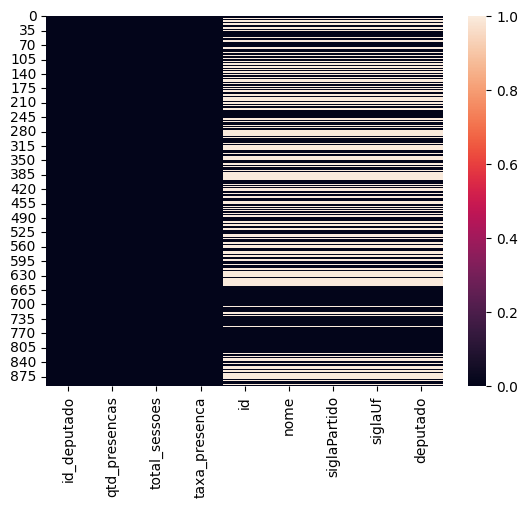

In [21]:
sns.heatmap(df_dep.isna())

In [ ]:
#titanic.deck.isna().value_counts()

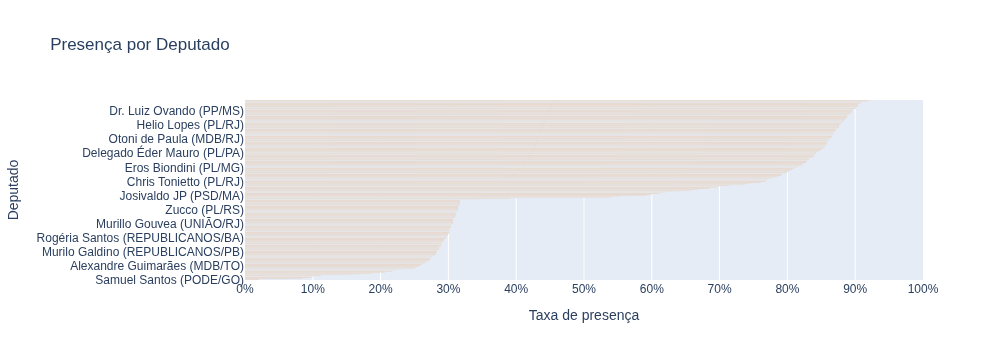

In [20]:
import plotly.express as px

palette_main = "#ff7f0e"

df_plot1 = df_dep.sort_values("taxa_presenca", ascending=True)

fig1 = px.bar(
    df_plot1,
    x="taxa_presenca",          # continua sendo fração 0–1
    y="deputado",
    orientation="h",
    labels={
        "taxa_presenca": "Taxa de presença",
        "deputado": "Deputado",
    },
    title="Presença por Deputado",
    color_discrete_sequence=[palette_main],
)

# Forçar o eixo num intervalo de 0 a 1
fig1.update_xaxes(
    range=[0, 1],     # eixo sempre de 0 a 1
    tick0=0,          # começa em 0
    dtick=0.1,        # passo de 0.1  ->  10%
    tickformat=".0%", # 0.0 -> 0%, 0.85 -> 85%
)

fig1.show()


In [22]:
df_dep.to_csv("../../data/graphs/df_dep_presenca.csv", index=False)
